In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
#Load the Dataset
customer_df = pd.read_csv("FinTrust_Customer_Data.csv")
print(customer_df.shape)
transaction_df = pd.read_csv("FinTrust_Transaction_Data.csv")
print(transaction_df.shape)

(1500, 12)
(12000, 11)


In [20]:
#Columns
print(customer_df.columns.tolist())

['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']


In [21]:
print(transaction_df.columns.tolist())

['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag']


In [22]:
customer_df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [23]:
transaction_df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


In [24]:
#Inspect the Data
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   object 
 1   Customer_Name             1500 non-null   object 
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   object 
 4   City                      1500 non-null   object 
 5   Customer_Segment          1500 non-null   object 
 6   Account_Type              1500 non-null   object 
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   object 
 10  Preferred_Channel         1500 non-null   object 
 11  Account_Status            1500 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 140.8+ KB


In [30]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  object 
 1   Customer_ID                12000 non-null  object 
 2   Transaction_DateTime       12000 non-null  object 
 3   Transaction_Type           12000 non-null  object 
 4   Amount_NGN                 12000 non-null  float64
 5   Channel                    12000 non-null  object 
 6   Device_Type                11904 non-null  object 
 7   Location                   11904 non-null  object 
 8   International_Transaction  12000 non-null  object 
 9   Transaction_Status         12000 non-null  object 
 10  Risk_Review_Flag           12000 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.0+ MB


In [32]:
#Missing Values
print("Customer Missing Values:")
print(customer_df.isnull().sum())

Customer Missing Values:
Customer_ID                 0
Customer_Name               0
Age                         0
Gender                      0
City                        0
Customer_Segment            0
Account_Type                0
Tenure_Months               0
Digital_Engagement_Score    0
Monthly_Income_Band         0
Preferred_Channel           0
Account_Status              0
dtype: int64


In [33]:
print("\nTransaction Missing Values:")
print(transaction_df.isnull().sum())


Transaction Missing Values:
Transaction_ID                0
Customer_ID                   0
Transaction_DateTime          0
Transaction_Type              0
Amount_NGN                    0
Channel                       0
Device_Type                  96
Location                     96
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
dtype: int64


In [35]:
#Numerical Values
customer_df.describe()

,Age,Tenure_Months,Digital_Engagement_Score
count,1500.000000,1500.000000,1500.000000
mean,41.587333,49.858667,67.954000
std,13.733127,27.910990,17.555376
min,18.000000,1.000000,16.700000
25%,29.750000,26.000000,56.100000
50%,42.000000,51.000000,68.000000
75%,53.000000,74.000000,80.925000
max,65.000000,96.000000,100.000000


In [36]:
transaction_df.describe()

,Amount_NGN
count,12000.000000
mean,46706.446238
std,86028.715234
min,100.170000
25%,2192.220000
50%,10305.935000
75%,48484.475000
max,693454.450000


In [37]:
#Categorical values
for column in customer_df.select_dtypes(include='object').columns:
    print(f"\n{column}:")
    print(customer_df[column].value_counts())


Customer_ID:
Customer_ID
FT-C00001    1
FT-C00998    1
FT-C01007    1
FT-C01006    1
FT-C01005    1
            ..
FT-C00498    1
FT-C00497    1
FT-C00496    1
FT-C00495    1
FT-C01500    1
Name: count, Length: 1500, dtype: int64

Customer_Name:
Customer_Name
Grace Williams     16
Daniel Bello       15
Zainab Williams    15
Grace Garba        14
Ada Garba          14
                   ..
Yusuf Williams      3
Emeka Ojo           3
Samuel Adeyemi      3
Mariam Mohammed     2
Amina Adeyemi       2
Name: count, Length: 180, dtype: int64

Gender:
Gender
Male                 727
Female               722
Prefer not to say     51
Name: count, dtype: int64

City:
City
Lagos            488
Abuja            223
Port Harcourt    172
Kano             159
Ibadan           148
Enugu            108
Kaduna           103
Benin City        99
Name: count, dtype: int64

Customer_Segment:
Customer_Segment
Everyday    711
Premium     295
Student     278
SME         216
Name: count, dtype: int64

Account_

In [38]:
for column in transaction_df.select_dtypes(include='object').columns:
    print(f"\n{column}:")
    print(transaction_df[column].value_counts())


Transaction_ID:
Transaction_ID
FT-T000001    1
FT-T008004    1
FT-T007995    1
FT-T007996    1
FT-T007997    1
             ..
FT-T004003    1
FT-T004004    1
FT-T004005    1
FT-T004006    1
FT-T012000    1
Name: count, Length: 12000, dtype: int64

Customer_ID:
Customer_ID
FT-C01296    20
FT-C00965    19
FT-C00209    18
FT-C01487    18
FT-C00351    18
             ..
FT-C00003     2
FT-C00710     2
FT-C01292     1
FT-C00983     1
FT-C00520     1
Name: count, Length: 1500, dtype: int64

Transaction_DateTime:
Transaction_DateTime
1/1/2026 0:00      1
3/2/2026 0:39      1
3/1/2026 23:02     1
3/1/2026 23:13     1
3/1/2026 23:23     1
                  ..
1/31/2026 0:25     1
1/31/2026 0:35     1
1/31/2026 0:46     1
1/31/2026 0:57     1
3/31/2026 23:59    1
Name: count, Length: 12000, dtype: int64

Transaction_Type:
Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, 

In [41]:
#Prepare the Dataset
transaction_df['Transaction_DateTime'] = pd.to_datetime(
    transaction_df['Transaction_DateTime'],
    errors='coerce'
)

In [43]:
print(transaction_df['Transaction_DateTime'].dtypes)


datetime64[ns]


In [45]:
transaction_df['Transaction_DateTime'].isnull().sum()

np.int64(0)

In [46]:
#Time Columnns
transaction_df['Year'] = transaction_df['Transaction_DateTime'].dt.year
transaction_df['Month'] = transaction_df['Transaction_DateTime'].dt.month
transaction_df['Month_Name'] = transaction_df['Transaction_DateTime'].dt.month_name()
transaction_df['Date'] = transaction_df['Transaction_DateTime'].dt.date

In [47]:
transaction_df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Year,Month,Month_Name,Date
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,2026,1,January,2026-01-01
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,2026,1,January,2026-01-01
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,2026,1,January,2026-01-01
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,2026,1,January,2026-01-01
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,2026,1,January,2026-01-01


In [48]:
#Fields will be using for our analysis
transaction_df[
    [
        'Customer_ID',
        'Transaction_DateTime',
        'Transaction_Type',
        'Amount_NGN',
        'Channel',
        'Transaction_Status',
        'International_Transaction',
        'Risk_Review_Flag'
    ]
].head()

,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Transaction_Status,International_Transaction,Risk_Review_Flag
0,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Reversed,No,Yes
1,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Successful,No,Yes
2,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,Successful,No,No
3,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Successful,No,No
4,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,Successful,No,No


In [53]:
#EDA
#1.Customer Segment -How does transaction activity and transaction value differ across customer segments?
segment_analysis = transaction_df.merge(
    customer_df[['Customer_ID', 'Customer_Segment']],
    on='Customer_ID',
    how='left'
)

segment_summary = segment_analysis.groupby('Customer_Segment').agg(
    Total_Customers=('Customer_ID', 'nunique'),
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

segment_summary


,Customer_Segment,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,Everyday,711,5644,2.614589e+08,46325.110027
1,Premium,295,2361,1.077512e+08,45637.948251
2,SME,216,1706,8.379137e+07,49115.692679
3,Student,278,2289,1.074759e+08,46953.196300


In [54]:
#2.Transaction Type -Which transaction types have the highest transaction volume and value?
transaction_type_summary = transaction_df.groupby('Transaction_Type').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

transaction_type_summary = transaction_type_summary.sort_values(
    'Total_Transaction_Value',
    ascending=False
)

transaction_type_summary

,Transaction_Type,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
5,Transfer,3549,2.379167e+08,67037.672699
4,Deposit,1328,1.309851e+08,98633.328200
2,Card Purchase,3033,8.586341e+07,28309.730887
3,Cash Withdrawal,1430,6.777236e+07,47393.260217
1,Bill Payment,1475,2.816365e+07,19093.998312
0,Airtime/Data,1185,9.776171e+06,8249.933494


In [55]:
#3.Transaction Amount -What is the distribution of transaction amounts, and what patterns or unusual values can be observed?
transaction_df['Amount_NGN'].describe()

count     12000.000000
mean      46706.446238
std       86028.715234
min         100.170000
25%        2192.220000
50%       10305.935000
75%       48484.475000
max      693454.450000
Name: Amount_NGN, dtype: float64

In [58]:
# 4.Transaction Channel -Which channels are most frequently used, and how does transaction value differ across channels?
channel_summary = transaction_df.groupby('Channel').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

channel_summary = channel_summary.sort_values(
    'Total_Transactions',
    ascending=False
)

channel_summary

,Channel,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
1,Mobile App,5102,2.401044e+08,47060.832064
2,POS,2393,1.043467e+08,43604.964994
4,Web,1869,8.932500e+07,47792.937368
0,ATM,1747,8.394235e+07,48049.430011
3,USSD,889,4.275895e+07,48097.811316


In [59]:
#5.Transaction Status -What proportion of transactions are successful, failed, pending, or reversed?
status_summary = transaction_df['Transaction_Status'].value_counts().reset_index()

status_summary.columns = [
    'Transaction_Status',
    'Total_Transactions'
]

status_summary['Percentage'] = (
    status_summary['Total_Transactions']
    / len(transaction_df)
    * 100
)

status_summary

,Transaction_Status,Total_Transactions,Percentage
0,Successful,10856,90.466667
1,Failed,630,5.250000
2,Reversed,326,2.716667
3,Pending,188,1.566667


In [60]:
#6.International Transactions -How do international transactions compare with domestic 
#transactions in terms of volume and transaction value?
international_summary = transaction_df.groupby(
    'International_Transaction'
).agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

international_summary

,International_Transaction,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,No,11520,5.404816e+08,46916.803036
1,Yes,480,1.999578e+07,41657.883063


In [61]:
#7.Customer Behaviour -What patterns of transaction frequency and transaction value are observed across customers?
customer_behavior = transaction_df.groupby('Customer_ID').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

customer_behavior.head()

,Customer_ID,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,FT-C00001,7,389228.44,55604.062857
1,FT-C00002,5,262429.47,52485.894000
2,FT-C00003,2,30819.66,15409.830000
3,FT-C00004,9,118140.65,13126.738889
4,FT-C00005,7,282577.99,40368.284286


In [62]:
#Most Active Customers
customer_behavior.sort_values(
    'Total_Transactions',
    ascending=False
).head(10)

,Customer_ID,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
1295,FT-C01296,20,783519.64,39175.982000
964,FT-C00965,19,376271.52,19803.764211
356,FT-C00357,18,1713516.28,95195.348889
208,FT-C00209,18,1063845.37,59102.520556
350,FT-C00351,18,649777.49,36098.749444
1486,FT-C01487,18,513210.81,28511.711667
815,FT-C00816,17,1611209.24,94777.014118
1036,FT-C01037,17,879343.45,51726.085294
1422,FT-C01423,17,633040.78,37237.692941
958,FT-C00959,17,909929.58,53525.269412


In [63]:
#Customers with the highest transactions
customer_behavior.sort_values(
    'Total_Transaction_Value',
    ascending=False
).head(10)

,Customer_ID,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
1074,FT-C01075,10,1713942.51,171394.251000
356,FT-C00357,18,1713516.28,95195.348889
815,FT-C00816,17,1611209.24,94777.014118
689,FT-C00690,12,1522279.61,126856.634167
22,FT-C00023,11,1440772.53,130979.320909
106,FT-C00107,15,1386146.39,92409.759333
30,FT-C00031,10,1354111.51,135411.151000
725,FT-C00726,11,1347878.51,122534.410000
1329,FT-C01330,10,1333820.19,133382.019000
398,FT-C00399,16,1318642.71,82415.169375


In [64]:
#8. Risk_Review Patterns -What transaction patterns are associated with Risk Review Flags?
risk_summary = transaction_df.groupby('Risk_Review_Flag').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Transaction_Value=('Amount_NGN', 'sum'),
    Average_Transaction_Value=('Amount_NGN', 'mean')
).reset_index()

risk_summary

,Risk_Review_Flag,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,No,9648,3.986937e+08,41323.976310
1,Yes,2352,1.617836e+08,68785.557572


In [65]:
#Detailed risk review patterns
risk_by_type = pd.crosstab(
    transaction_df['Transaction_Type'],
    transaction_df['Risk_Review_Flag']
)

risk_by_type

Risk_Review_Flag,No,Yes
Transaction_Type,,
Airtime/Data,1005,180
Bill Payment,1286,189
Card Purchase,2638,395
Cash Withdrawal,1068,362
Deposit,1113,215
Transfer,2538,1011


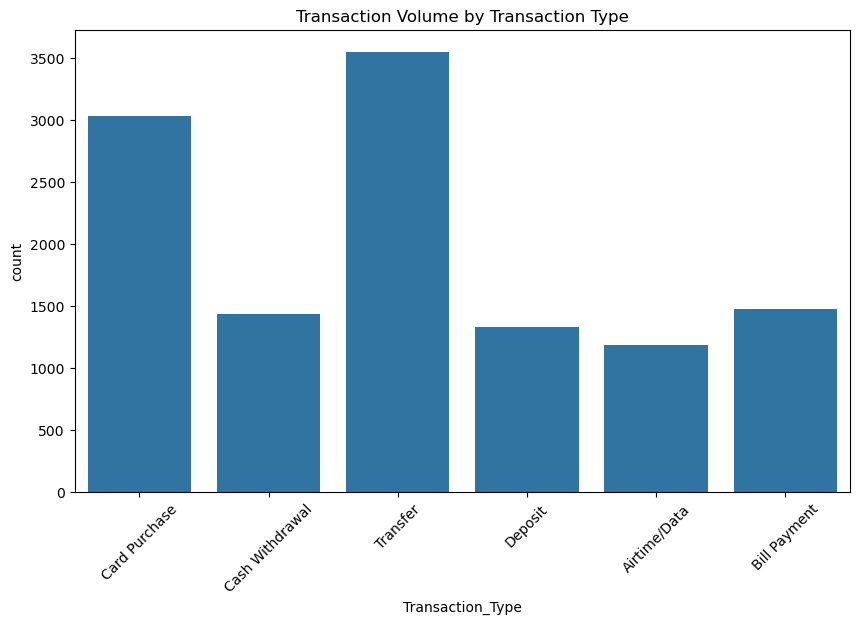

In [66]:
#VISUALIZATIONS
#1.Transaction Volumes by Transaction Types
plt.figure(figsize=(10,6))
sns.countplot(data=transaction_df, x='Transaction_Type')
plt.title('Transaction Volume by Transaction Type')
plt.xticks(rotation=45)
plt.show()

What does the visual show?
This chart shows the number of transactions recorded for each transaction type, 
such as transfers, deposits, withdrawals, bill payments, or purchases.

Why is it important?
It helps identify which transaction services are most frequently used by 
customers and highlights customer transaction preferences.

Business insight
FinTrust can determine which transaction types generate the highest customer activity. 
High-volume transaction types may require additional resources, improved system performance, or targeted customer services.
Low-volume transaction types may require further investigation to understand customer adoption.

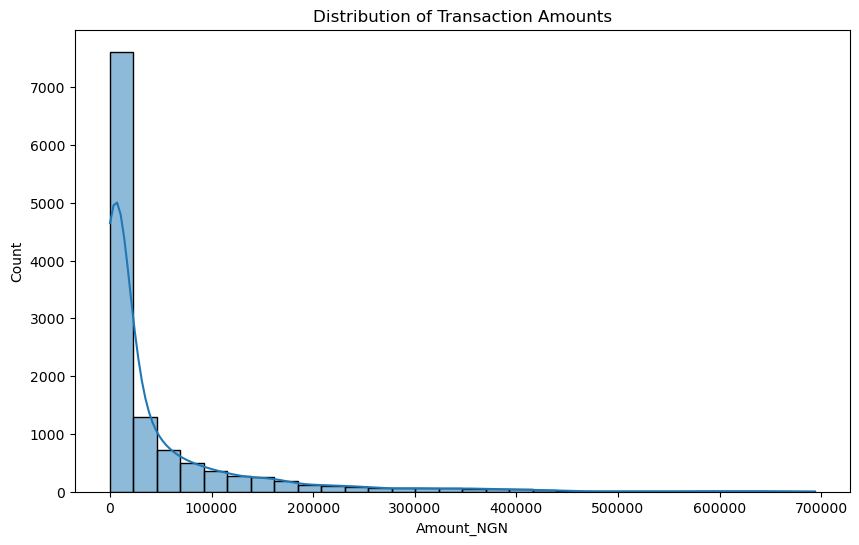

In [67]:
#2.Distribution of Transaction Amount
plt.figure(figsize=(10,6))
sns.histplot(transaction_df['Amount_NGN'], bins=30, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

What does the visual show?
The histogram shows how transaction amounts are distributed across all transactions, 
indicating whether most transactions are small, medium, or large.

Why is it important?
It helps understand typical customer transaction behaviour and identifies 
whether unusually high or low transaction values exist.

Business insight
FinTrust can use this analysis to understand normal transaction patterns and 
identify large-value transactions that may require additional monitoring or risk assessment.

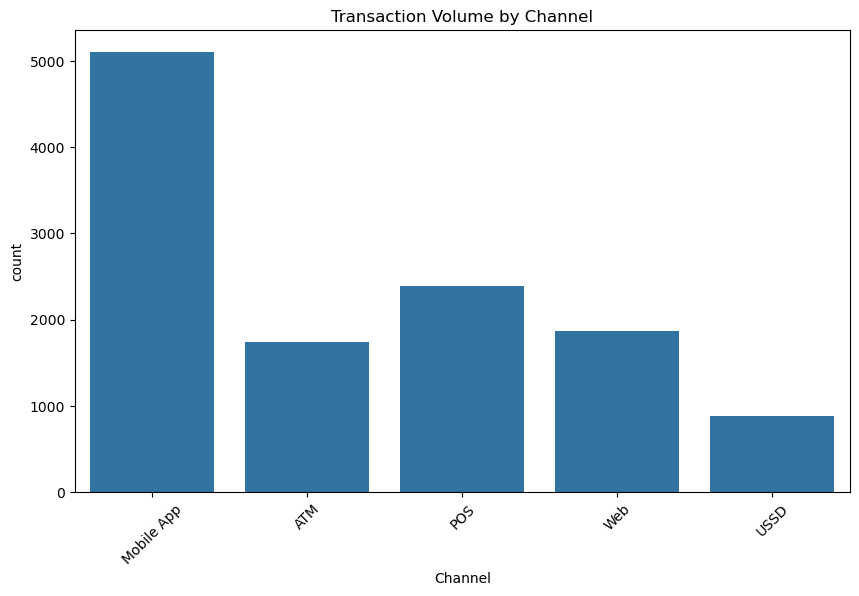

In [68]:
#3.Transaction Volume by Channel
plt.figure(figsize=(10,6))
sns.countplot(data=transaction_df, x='Channel')
plt.title('Transaction Volume by Channel')
plt.xticks(rotation=45)
plt.show()

What does the visual show?
This chart compares transaction volumes across channels such as Mobile App, ATM, Web, POS, Branch, or USSD.

Why is it important?
It helps identify how customers interact with FinTrust's services and shows which channels are most frequently used.

Business insight
The results can support channel improvement decisions, digital banking strategies,
and customer service planning. Frequently used channels may require more investment, 
while low-usage channels may need additional promotion or evaluation.

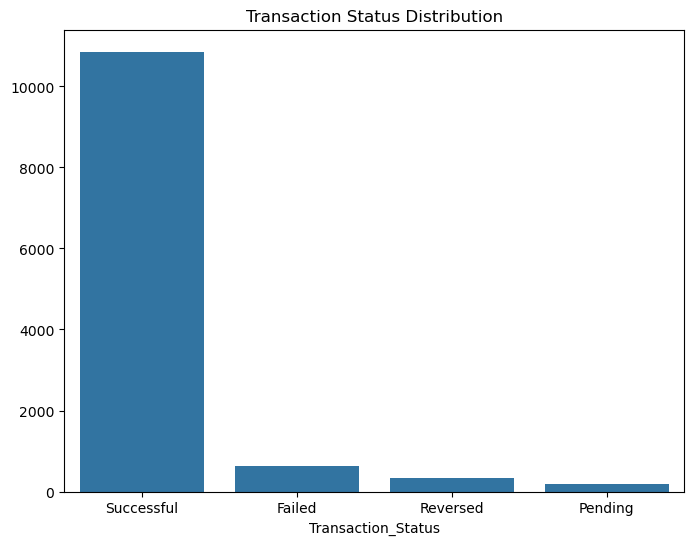

In [69]:
#4. Transaction Status Distribution
plt.figure(figsize=(8,6))

status_summary = transaction_df['Transaction_Status'].value_counts()

sns.barplot(
    x=status_summary.index,
    y=status_summary.values
)

plt.title('Transaction Status Distribution')
plt.show()

What does the visual show?
The chart shows the number of transactions that are successful, failed, pending, or reversed.

Why is it important?
Transaction outcomes directly affect customer experience and operational efficiency.

Business insight
A high percentage of successful transactions indicates good system performance. Larger numbers of failed, 
pending, or reversed transactions may indicate operational issues that require further investigation.

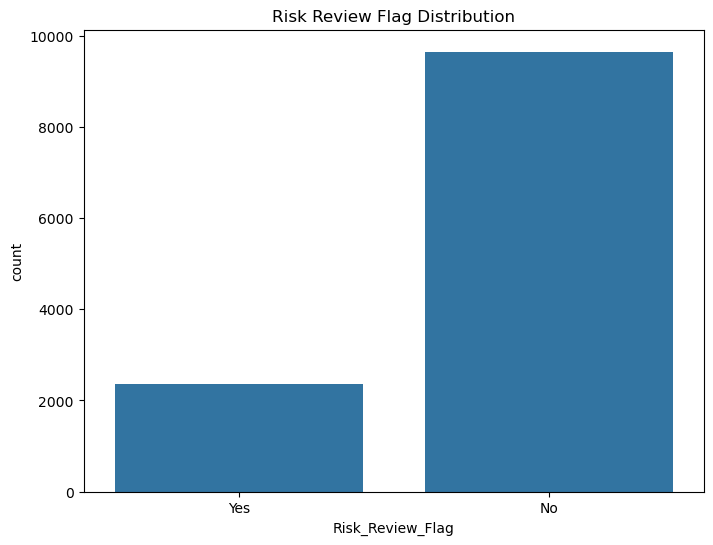

In [70]:
#5. Risk Review Flag Analysis
plt.figure(figsize=(8,6))

sns.countplot(
    data=transaction_df,
    x='Risk_Review_Flag'
)

plt.title('Risk Review Flag Distribution')
plt.show()

What does the visual show?
This chart compares the number of transactions with and without Risk Review Flags.

Why is it important?
It helps identify the proportion of transactions that require additional review or monitoring.

Business insight
FinTrust can use this analysis to understand transaction patterns associated with 
Risk Review Flags and improve risk management processes.

#Risk Review flag does not automatically mean fraud.